<a href="https://colab.research.google.com/github/bedkemanojkumar/mini-ml-projects-for-practice/blob/main/SentimentalAnalysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install pandas numpy nltk scikit-learn matplotlib seaborn

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving archive.zip to archive (1).zip


In [ ]:
import zipfile

with zipfile.ZipFile('archive.zip', 'r') as zip_ref:
    zip_ref.extractall()

print("Extraction Complete")

Extraction Complete


In [ ]:
import os

os.listdir()

['.config',
 'drive',
 'Tweets.csv',
 'archive (1).zip',
 'bert_results',
 'database.sqlite',
 'archive.zip',
 'sample_data']

In [ ]:
import pandas as pd

df = pd.read_csv("Tweets.csv")

In [ ]:
print(df.shape)

(14640, 15)


In [ ]:
df.head()


,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
0,570306133677760513,neutral,1.0000,NaN,NaN,Virgin America,NaN,cairdin,NaN,0,@VirginAmerica What @dhepburn said.,NaN,2015-02-24 11:35:52 -0800,NaN,Eastern Time (US & Canada)
1,570301130888122368,positive,0.3486,NaN,0.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica plus you've added commercials t...,NaN,2015-02-24 11:15:59 -0800,NaN,Pacific Time (US & Canada)
2,570301083672813571,neutral,0.6837,NaN,NaN,Virgin America,NaN,yvonnalynn,NaN,0,@VirginAmerica I didn't today... Must mean I n...,NaN,2015-02-24 11:15:48 -0800,Lets Play,Central Time (US & Canada)
3,570301031407624196,negative,1.0000,Bad Flight,0.7033,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica it's really aggressive to blast...,NaN,2015-02-24 11:15:36 -0800,NaN,Pacific Time (US & Canada)
4,570300817074462722,negative,1.0000,Can't Tell,1.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica and it's a really big bad thing...,NaN,2015-02-24 11:14:45 -0800,NaN,Pacific Time (US & Canada)


In [ ]:
print(df.columns)

Index(['tweet_id', 'airline_sentiment', 'airline_sentiment_confidence',
       'negativereason', 'negativereason_confidence', 'airline',
       'airline_sentiment_gold', 'name', 'negativereason_gold',
       'retweet_count', 'text', 'tweet_coord', 'tweet_created',
       'tweet_location', 'user_timezone'],
      dtype='object')


In [ ]:
df = df[['text', 'airline_sentiment']]

In [ ]:
df.head()

,text,airline_sentiment
0,@VirginAmerica What @dhepburn said.,neutral
1,@VirginAmerica plus you've added commercials t...,positive
2,@VirginAmerica I didn't today... Must mean I n...,neutral
3,@VirginAmerica it's really aggressive to blast...,negative
4,@VirginAmerica and it's a really big bad thing...,negative


In [ ]:
df.isnull().sum()

,0
text,0
airline_sentiment,0


In [ ]:
#Check Sentiment Distribution
print(df['airline_sentiment'].value_counts())

airline_sentiment
negative    9178
neutral     3099
positive    2363
Name: count, dtype: int64


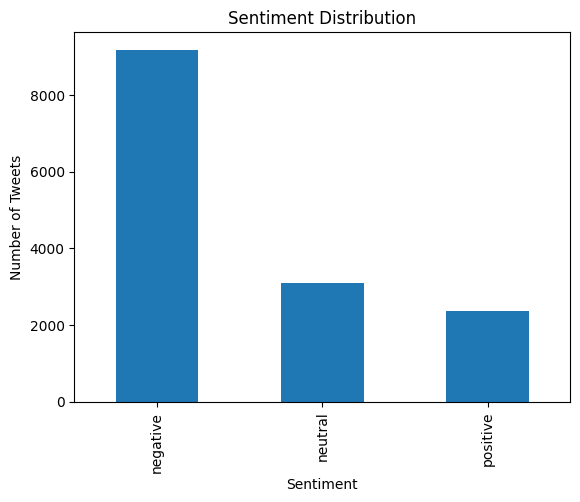

In [ ]:
import matplotlib.pyplot as plt

df['airline_sentiment'].value_counts().plot(kind='bar')

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Tweets")

plt.show()
#Visualize Distribution

In [ ]:
# Text Cleaning.


In [ ]:
import re

In [ ]:
# cleaning function
def clean_text(text):

    text = text.lower()

    text = re.sub(r"http\S+", "", text)

    text = re.sub(r"@\w+", "", text)

    text = re.sub(r"#\w+", "", text)

    text = re.sub(r"[^a-zA-Z\s]", "", text)

    text = re.sub(r"\s+", " ", text)

    return text.strip()

In [ ]:
#Apply Cleaning
df['clean_text'] = df['text'].apply(clean_text)

In [ ]:
# Compare before after
for i in range(8):
    print("Original:", df['text'][i])
    print("Cleaned :", df['clean_text'][i])
    print("-"*80)

Original: @VirginAmerica What @dhepburn said.
Cleaned : what said
--------------------------------------------------------------------------------
Original: @VirginAmerica plus you've added commercials to the experience... tacky.
Cleaned : plus youve added commercials to the experience tacky
--------------------------------------------------------------------------------
Original: @VirginAmerica I didn't today... Must mean I need to take another trip!
Cleaned : i didnt today must mean i need to take another trip
--------------------------------------------------------------------------------
Original: @VirginAmerica it's really aggressive to blast obnoxious "entertainment" in your guests' faces &amp; they have little recourse
Cleaned : its really aggressive to blast obnoxious entertainment in your guests faces amp they have little recourse
--------------------------------------------------------------------------------
Original: @VirginAmerica and it's a really big bad thing about it
C

In [ ]:
# Tokenization
import nltk
nltk.download('punkt')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [ ]:
from nltk.tokenize import word_tokenize

In [ ]:
import nltk

nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [ ]:
# Apply
df['tokens'] = df['clean_text'].apply(word_tokenize)

In [ ]:
# Stop word
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [ ]:
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

In [ ]:
def remove_stopwords(tokens):
    return [word for word in tokens if word not in stop_words]

In [ ]:
df['tokens'] = df['tokens'].apply(remove_stopwords)

In [ ]:
df[['clean_text', 'tokens']].head()

,clean_text,tokens
0,what said,[said]
1,plus youve added commercials to the experience...,"[plus, youve, added, commercials, experience, ..."
2,i didnt today must mean i need to take another...,"[didnt, today, must, mean, need, take, another..."
3,its really aggressive to blast obnoxious enter...,"[really, aggressive, blast, obnoxious, enterta..."
4,and its a really big bad thing about it,"[really, big, bad, thing]"


In [ ]:
#Lemmatization
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [ ]:
from nltk.stem import WordNetLemmatizer

lemmatizer = WordNetLemmatizer()

In [ ]:
def lemmatize_words(tokens):
    return [lemmatizer.lemmatize(word) for word in tokens]

In [ ]:
df['tokens'] = df['tokens'].apply(lemmatize_words)

In [ ]:
df[['tokens']].head()

,tokens
0,[said]
1,"[plus, youve, added, commercial, experience, t..."
2,"[didnt, today, must, mean, need, take, another..."
3,"[really, aggressive, blast, obnoxious, enterta..."
4,"[really, big, bad, thing]"


In [ ]:
#Convert Tokens Back to Text
df['final_text'] = df['tokens'].apply(lambda x: " ".join(x))

In [ ]:
df[['final_text']].head()

,final_text
0,said
1,plus youve added commercial experience tacky
2,didnt today must mean need take another trip
3,really aggressive blast obnoxious entertainmen...
4,really big bad thing


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [ ]:
tfidf = TfidfVectorizer(max_features=5000)

In [ ]:
X = tfidf.fit_transform(df['final_text'])

In [ ]:
y = df['airline_sentiment']

In [ ]:
print(X.shape)

(14640, 5000)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
print(X_train.shape)
print(X_test.shape)

(11712, 5000)
(2928, 5000)


In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [ ]:
train_acc = model.score(X_train, y_train)

print("Train Accuracy:", train_acc)

Train Accuracy: 0.858521174863388


In [ ]:
test_acc = model.score(X_test, y_test)

print("Test Accuracy:", test_acc)

Test Accuracy: 0.796448087431694


In [ ]:
y_pred = model.predict(X_test)

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

    negative       0.82      0.94      0.88      1889
     neutral       0.66      0.49      0.56       580
    positive       0.82      0.60      0.69       459

    accuracy                           0.80      2928
   macro avg       0.77      0.68      0.71      2928
weighted avg       0.79      0.80      0.78      2928



In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[1772   88   29]
 [ 264  284   32]
 [ 122   61  276]]


In [ ]:
#Test on Unseen Tweets
unseen_tweets = [

    # Negative
    "The flight was delayed for five hours and nobody informed us",
    "Lost my baggage and customer support was useless",
    "Worst airline experience ever",
    "My flight got cancelled at the last minute",
    "The seats were uncomfortable and the food was terrible",
    "Still waiting at the airport after three delays",
    "Customer service did not answer any of my calls",
    "The boarding process was chaotic and poorly managed",
    "They charged me extra for everything",
    "I will never fly with this airline again",

    # Positive
    "Excellent customer service and very friendly staff",
    "The flight departed on time and arrived early",
    "Thank you for making my travel experience smooth and comfortable",
    "The cabin crew was extremely helpful throughout the journey",
    "I am very satisfied with the service provided",
    "Quick check in process and professional staff",
    "The seats were comfortable and the food was delicious",
    "Amazing experience from booking to landing",
    "I appreciate the prompt response from customer support",
    "Best airline experience I have had in years",

    # Neutral
    "The flight departed at the scheduled time",
    "I am currently waiting for boarding",
    "The ticket price was average compared to other airlines",
    "Traveling from New York to Chicago today",
    "The aircraft has 180 seats",
    "The flight duration was two hours",
    "Boarding started at 8 PM",
    "The airline announced a gate change",
    "Checked in online before arriving at the airport",
    "The weather caused some delays today",

    # Mixed Sentiment
    "The flight was delayed but the staff handled the situation well",
    "Customer service was excellent although the flight was late",
    "The seats were comfortable but the food was disappointing",
    "Check in was smooth but baggage delivery took too long",
    "The crew was friendly but the flight got cancelled",
    "The journey was pleasant except for the long delay",
    "Good service but expensive ticket prices",
    "The airline resolved my issue after several complaints",
    "The flight arrived safely but much later than expected",
    "Nice staff but poor communication regarding delays",

    # Difficult / Ambiguous
    "The flight was okay nothing special",
    "Average experience overall",
    "Not the best flight but not the worst either",
    "Everything worked as expected",
    "Service was acceptable",
    "The journey was uneventful",
    "I have mixed feelings about this flight",
    "It was fine",
    "Nothing remarkable happened during the trip",
    "The airline met my expectations",

    # Sarcasm / Challenging Cases
    "Great another five hour delay exactly what I needed",
    "Fantastic customer service if ignoring passengers is the goal",
    "Wonderful now I can spend my entire day at the airport",
    "Amazing airline they managed to lose my luggage twice",
    "Perfect way to ruin a vacation",
    "Thanks for cancelling my flight at midnight",
    "Excellent job making everyone miss their connections",
    "I really enjoyed sitting on the runway for three hours",
    "Best customer support ever they never replied",
    "What a great experience getting stranded overnight"
]

In [ ]:
def preprocess_text(text):

    text = clean_text(text)

    tokens = text.split()

    tokens = [word for word in tokens if word not in stop_words]

    tokens = [lemmatizer.lemmatize(word) for word in tokens]

    return " ".join(tokens)

In [ ]:
processed_tweets = [preprocess_text(tweet) for tweet in unseen_tweets]

In [ ]:
X_unseen = tfidf.transform(processed_tweets)

In [ ]:
predictions = model.predict(X_unseen)

for tweet, pred in zip(unseen_tweets, predictions):
    print(f"Tweet: {tweet}")
    print(f"Prediction: {pred}")
    print("-"*50)

Tweet: The flight was delayed for five hours and nobody informed us
Prediction: negative
--------------------------------------------------
Tweet: Lost my baggage and customer support was useless
Prediction: negative
--------------------------------------------------
Tweet: Worst airline experience ever
Prediction: negative
--------------------------------------------------
Tweet: My flight got cancelled at the last minute
Prediction: negative
--------------------------------------------------
Tweet: The seats were uncomfortable and the food was terrible
Prediction: negative
--------------------------------------------------
Tweet: Still waiting at the airport after three delays
Prediction: negative
--------------------------------------------------
Tweet: Customer service did not answer any of my calls
Prediction: negative
--------------------------------------------------
Tweet: The boarding process was chaotic and poorly managed
Prediction: negative
---------------------------------

In [ ]:
#Clear Negative

#10/10 correct

#Clear Positive

#Around 7/10 correct

#Neutral

#Around 2–3/10 correct

#Mixed

#Mostly classified as negative

#Sarcasm

#About 50% correct

In [ ]:
# Model SVM.
from sklearn.svm import LinearSVC

In [ ]:
svm_model = LinearSVC()

In [ ]:
svm_model.fit(X_train, y_train)

LinearSVC()

In [ ]:
train_acc_svm = svm_model.score(X_train, y_train)

print("Train Accuracy:", train_acc_svm)

Train Accuracy: 0.9146174863387978


In [ ]:
test_acc_svm = svm_model.score(X_test, y_test)

print("Test Accuracy:", test_acc_svm)

Test Accuracy: 0.7961065573770492


In [ ]:
#Train = 91.48%
#Test = 79.61%

#Gap = 11.87%
#SVM is showing more signs of overfitting

In [ ]:
y_pred_svm = svm_model.predict(X_test)

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_svm))

              precision    recall  f1-score   support

    negative       0.85      0.91      0.88      1889
     neutral       0.62      0.52      0.57       580
    positive       0.74      0.69      0.71       459

    accuracy                           0.80      2928
   macro avg       0.74      0.71      0.72      2928
weighted avg       0.79      0.80      0.79      2928



In [ ]:
#Neutral Recall
#Positive Recall

In [ ]:
from sklearn.metrics import confusion_matrix

cm_svm = confusion_matrix(y_test, y_pred_svm)

print(cm_svm)

[[1712  128   49]
 [ 216  304   60]
 [  89   55  315]]


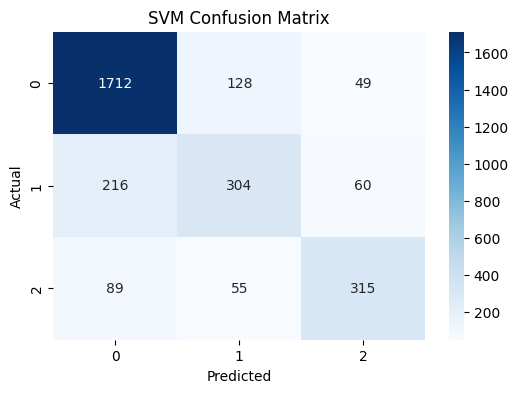

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))

sns.heatmap(
    cm_svm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("SVM Confusion Matrix")

plt.show()

In [ ]:
# conclusion Although SVM achieved a higher training accuracy of 91.48%, its testing accuracy remained similar to Logistic Regression at 79.61%. This suggests that SVM learned the training data more aggressively without providing a corresponding,
# improvement on unseen data

In [ ]:
#Logistic Regression is arguably the better-balanced model because it achieves the same test performance with less overfitting

In [ ]:
#Check for unseen_tweets
svm_predictions = svm_model.predict(X_unseen)

for tweet, pred in zip(unseen_tweets, svm_predictions):
    print("Tweet:", tweet)
    print("Prediction:", pred)
    print("-"*60)

Tweet: The flight was delayed for five hours and nobody informed us
Prediction: negative
------------------------------------------------------------
Tweet: Lost my baggage and customer support was useless
Prediction: negative
------------------------------------------------------------
Tweet: Worst airline experience ever
Prediction: negative
------------------------------------------------------------
Tweet: My flight got cancelled at the last minute
Prediction: negative
------------------------------------------------------------
Tweet: The seats were uncomfortable and the food was terrible
Prediction: negative
------------------------------------------------------------
Tweet: Still waiting at the airport after three delays
Prediction: negative
------------------------------------------------------------
Tweet: Customer service did not answer any of my calls
Prediction: negative
------------------------------------------------------------
Tweet: The boarding process was chaotic and

In [ ]:
lr_predictions = model.predict(X_unseen)

svm_predictions = svm_model.predict(X_unseen)

for i in range(len(unseen_tweets)):
    print(f"Tweet: {unseen_tweets[i]}")
    print(f"Logistic Regression: {lr_predictions[i]}")
    print(f"SVM: {svm_predictions[i]}")
    print("-"*80)

Tweet: The flight was delayed for five hours and nobody informed us
Logistic Regression: negative
SVM: negative
--------------------------------------------------------------------------------
Tweet: Lost my baggage and customer support was useless
Logistic Regression: negative
SVM: negative
--------------------------------------------------------------------------------
Tweet: Worst airline experience ever
Logistic Regression: negative
SVM: negative
--------------------------------------------------------------------------------
Tweet: My flight got cancelled at the last minute
Logistic Regression: negative
SVM: negative
--------------------------------------------------------------------------------
Tweet: The seats were uncomfortable and the food was terrible
Logistic Regression: negative
SVM: negative
--------------------------------------------------------------------------------
Tweet: Still waiting at the airport after three delays
Logistic Regression: negative
SVM: negative
---

In [ ]:
import tensorflow as tf

print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y_lstm = label_encoder.fit_transform(df['airline_sentiment'])

print(y_lstm[:10])

[1 2 1 0 0 0 2 1 2 2]


In [ ]:
df['final_text']

,final_text
0,said
1,plus youve added commercial experience tacky
2,didnt today must mean need take another trip
3,really aggressive blast obnoxious entertainmen...
4,really big bad thing
...,...
14635,thank got different flight chicago
14636,leaving minute late flight warning communicati...
14637,please bring american airline
14638,money change flight dont answer phone suggesti...


In [ ]:
df['final_text'].head()

,final_text
0,said
1,plus youve added commercial experience tacky
2,didnt today must mean need take another trip
3,really aggressive blast obnoxious entertainmen...
4,really big bad thing


In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer

tokenizer = Tokenizer(
    num_words=10000,
    oov_token="<OOV>"
)

tokenizer.fit_on_texts(df['final_text'])

sequences = tokenizer.texts_to_sequences(df['final_text'])

print(sequences[:2])

[[130], [407, 408, 941, 1060, 108, 4949]]


In [ ]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

X_lstm = pad_sequences(
    sequences,
    maxlen=50,
    padding='post',
    truncating='post'
)

print(X_lstm.shape)

(14640, 50)


In [ ]:
print(X_lstm.shape)
print(y_lstm.shape)

(14640, 50)
(14640,)


In [ ]:
#Train-Test Split
from sklearn.model_selection import train_test_split

X_train_lstm, X_test_lstm, y_train_lstm, y_test_lstm = train_test_split(
    X_lstm,
    y_lstm,
    test_size=0.2,
    random_state=42
)

print(X_train_lstm.shape)
print(X_test_lstm.shape)

(11712, 50)
(2928, 50)


In [ ]:
import tensorflow as tf

tf.config.set_visible_devices([], 'GPU')

RuntimeError: Visible devices cannot be modified after being initialized

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout

lstm_model = Sequential([

    Embedding(
        input_dim=10000,
        output_dim=64
    ),

    LSTM(32, implementation=1),

    Dropout(0.3),

    Dense(16, activation='relu'),

    Dense(3, activation='softmax')
])

In [ ]:
#Compile the Model
lstm_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
lstm_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#Training
history = lstm_model.fit(
    X_train_lstm,
    y_train_lstm,
    epochs=3,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/3


InvalidArgumentError: Graph execution error:

Detected at node sequential_1_1/lstm_1_1/CudnnRNNV3 defined at (most recent call last):
  File "<frozen runpy>", line 198, in _run_module_as_main

  File "<frozen runpy>", line 88, in _run_code

  File "/usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py", line 37, in <module>

  File "/usr/local/lib/python3.12/dist-packages/traitlets/config/application.py", line 992, in launch_instance

  File "/usr/local/lib/python3.12/dist-packages/ipykernel/kernelapp.py", line 712, in start

  File "/usr/local/lib/python3.12/dist-packages/tornado/platform/asyncio.py", line 211, in start

  File "/usr/lib/python3.12/asyncio/base_events.py", line 645, in run_forever

  File "/usr/lib/python3.12/asyncio/base_events.py", line 1999, in _run_once

  File "/usr/lib/python3.12/asyncio/events.py", line 88, in _run

  File "/usr/local/lib/python3.12/dist-packages/ipykernel/kernelbase.py", line 510, in dispatch_queue

  File "/usr/local/lib/python3.12

In [ ]:
train_loss, train_acc = lstm_model.evaluate(
    X_train_lstm,
    y_train_lstm,
    verbose=0
)

test_loss, test_acc = lstm_model.evaluate(
    X_test_lstm,
    y_test_lstm,
    verbose=0
)

print("Train Accuracy:", train_acc)
print("Test Accuracy:", test_acc)

In [ ]:
import numpy as np

y_pred_prob = lstm_model.predict(X_test_lstm)

y_pred_lstm = np.argmax(
    y_pred_prob,
    axis=1
)

In [ ]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test_lstm,
        y_pred_lstm
    )
)

In [ ]:
#use class weights
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

In [ ]:
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_lstm),
    y=y_train_lstm
)

In [ ]:
class_weights = dict(
    enumerate(class_weights)
)

print(class_weights)

In [ ]:
#Rebuild Model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding,LSTM,Dense,Dropout

lstm_model = Sequential([

    Embedding(
        input_dim=10000,
        output_dim=64
    ),

    LSTM(64),

    Dropout(0.3),

    Dense(32, activation='relu'),

    Dense(3, activation='softmax')
])

In [ ]:
lstm_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
#Train with Class Weights
history = lstm_model.fit(
    X_train_lstm,
    y_train_lstm,
    epochs=5,
    batch_size=64,
    validation_split=0.2,
    class_weight=class_weights
)

In [ ]:
import torch

print(torch.cuda.is_available())

True


In [ ]:
import torch

print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
Tesla T4


In [ ]:
!pip install transformers datasets accelerate evaluate -q

In [ ]:
df = df[['final_text', 'airline_sentiment']]

df.head()

,final_text,airline_sentiment
0,said,neutral
1,plus youve added commercial experience tacky,positive
2,didnt today must mean need take another trip,neutral
3,really aggressive blast obnoxious entertainmen...,negative
4,really big bad thing,negative


In [ ]:
# encode labels
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

df['label'] = label_encoder.fit_transform(
    df['airline_sentiment']
)

print(label_encoder.classes_)

['negative' 'neutral' 'positive']


/tmp/ipykernel_3639/1990395597.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['label'] = label_encoder.fit_transform(


In [ ]:
#Train-Test Split
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df['label']
)

print(train_df.shape)
print(test_df.shape)

(11712, 3)
(2928, 3)


In [ ]:
#Convert to Hugging Face Dataset
from datasets import Dataset

train_dataset = Dataset.from_pandas(train_df)
test_dataset = Dataset.from_pandas(test_df)

In [ ]:
#Load BERT Tokenizer
from transformers import BertTokenizer

tokenizer = BertTokenizer.from_pretrained(
    "bert-base-uncased"
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [ ]:
#Tokenization Function
def tokenize_function(example):
    return tokenizer(
        example["final_text"],
        truncation=True,
        padding="max_length",
        max_length=128
    )

In [ ]:
train_dataset = train_dataset.map(
    tokenize_function,
    batched=True
)

test_dataset = test_dataset.map(
    tokenize_function,
    batched=True
)

Map:   0%|          | 0/11712 [00:00<?, ? examples/s]

Map:   0%|          | 0/2928 [00:00<?, ? examples/s]

In [ ]:
train_dataset = train_dataset.remove_columns(
    ["final_text", "airline_sentiment"]
)

test_dataset = test_dataset.remove_columns(
    ["final_text", "airline_sentiment"]
)

In [ ]:
train_dataset = train_dataset.rename_column(
    "label",
    "labels"
)

test_dataset = test_dataset.rename_column(
    "label",
    "labels"
)

In [ ]:
train_dataset.set_format("torch")
test_dataset.set_format("torch")

In [ ]:
!pip uninstall -y torch torchvision torchaudio -q

In [ ]:
from transformers import BertForSequenceClassification

model = BertForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=3
)

OSError: /usr/local/lib/python3.12/dist-packages/torchaudio/lib/_torchaudio.abi3.so: undefined symbol: aoti_torch_abi_version

In [ ]:
print(train_dataset)

In [ ]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./bert_results",

    eval_strategy="epoch",

    save_strategy="epoch",

    learning_rate=2e-5,

    per_device_train_batch_size=16,

    per_device_eval_batch_size=16,

    num_train_epochs=3,

    weight_decay=0.01,

    logging_steps=100,

    load_best_model_at_end=True,

    report_to="none"
)

In [ ]:
import evaluate
import numpy as np

accuracy = evaluate.load("accuracy")

In [ ]:
def compute_metrics(eval_pred):

    logits, labels = eval_pred

    predictions = np.argmax(
        logits,
        axis=-1
    )

    return accuracy.compute(
        predictions=predictions,
        references=labels
    )

In [ ]:
#Create Trainer
from transformers import Trainer

trainer = Trainer(
    model=model,

    args=training_args,

    train_dataset=train_dataset,

    eval_dataset=test_dataset,

    compute_metrics=compute_metrics
)

In [ ]:
!pip uninstall -y torchvision torchaudio torch -q

In [ ]:
!pip install torch==2.1.2 torchvision==0.16.2 torchaudio==2.1.2 -q

In [ ]:
!pip uninstall -y torch torchvision torchaudio -q

In [ ]:
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cpu -q

In [ ]:
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121 -q

In [ ]:
!pip install -U datasets transformers accelerate -q

In [ ]:
import os
os.environ["HF_HUB_DISABLE_SYMLINKS_WARNING"] = "1"

In [ ]:
trainer.train()

In [ ]:
results = trainer.evaluate()

print(results)

In [ ]:
predictions = trainer.predict(test_dataset)

In [ ]:
import numpy as np

y_pred = np.argmax(
    predictions.predictions,
    axis=1
)

y_true = predictions.label_ids

In [ ]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_true,
        y_pred
    )
)

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_true,
    y_pred
)

print(cm)

In [ ]:
#Test on Unseen Tweets
unseen_tweets = [

    # Negative
    "The flight was delayed for five hours and nobody informed us",
    "Lost my baggage and customer support was useless",
    "Worst airline experience ever",
    "My flight got cancelled at the last minute",
    "The seats were uncomfortable and the food was terrible",
    "Still waiting at the airport after three delays",
    "Customer service did not answer any of my calls",
    "The boarding process was chaotic and poorly managed",
    "They charged me extra for everything",
    "I will never fly with this airline again",

    # Positive
    "Excellent customer service and very friendly staff",
    "The flight departed on time and arrived early",
    "Thank you for making my travel experience smooth and comfortable",
    "The cabin crew was extremely helpful throughout the journey",
    "I am very satisfied with the service provided",
    "Quick check in process and professional staff",
    "The seats were comfortable and the food was delicious",
    "Amazing experience from booking to landing",
    "I appreciate the prompt response from customer support",
    "Best airline experience I have had in years",

    # Neutral
    "The flight departed at the scheduled time",
    "I am currently waiting for boarding",
    "The ticket price was average compared to other airlines",
    "Traveling from New York to Chicago today",
    "The aircraft has 180 seats",
    "The flight duration was two hours",
    "Boarding started at 8 PM",
    "The airline announced a gate change",
    "Checked in online before arriving at the airport",
    "The weather caused some delays today",

    # Mixed Sentiment
    "The flight was delayed but the staff handled the situation well",
    "Customer service was excellent although the flight was late",
    "The seats were comfortable but the food was disappointing",
    "Check in was smooth but baggage delivery took too long",
    "The crew was friendly but the flight got cancelled",
    "The journey was pleasant except for the long delay",
    "Good service but expensive ticket prices",
    "The airline resolved my issue after several complaints",
    "The flight arrived safely but much later than expected",
    "Nice staff but poor communication regarding delays",

    # Difficult / Ambiguous
    "The flight was okay nothing special",
    "Average experience overall",
    "Not the best flight but not the worst either",
    "Everything worked as expected",
    "Service was acceptable",
    "The journey was uneventful",
    "I have mixed feelings about this flight",
    "It was fine",
    "Nothing remarkable happened during the trip",
    "The airline met my expectations",

    # Sarcasm / Challenging Cases
    "Great another five hour delay exactly what I needed",
    "Fantastic customer service if ignoring passengers is the goal",
    "Wonderful now I can spend my entire day at the airport",
    "Amazing airline they managed to lose my luggage twice",
    "Perfect way to ruin a vacation",
    "Thanks for cancelling my flight at midnight",
    "Excellent job making everyone miss their connections",
    "I really enjoyed sitting on the runway for three hours",
    "Best customer support ever they never replied",
    "What a great experience getting stranded overnight"
]

In [ ]:
inputs = tokenizer(
    unseen_tweets,
    padding=True,
    truncation=True,
    max_length=128,
    return_tensors="pt"
)

In [ ]:
import torch

device = torch.device("cuda")

model.to(device)

inputs = {k: v.to(device) for k, v in inputs.items()}

In [ ]:
with torch.no_grad():
    outputs = model(**inputs)

predictions = torch.argmax(
    outputs.logits,
    dim=1
)

In [ ]:
label_map = {
    0: "negative",
    1: "neutral",
    2: "positive"
}

for tweet, pred in zip(unseen_tweets, predictions):
    print("Tweet:", tweet)
    print("Prediction:", label_map[pred.item()])
    print("-"*50)

In [ ]:
inputs = tokenizer(
    unseen_tweets,
    padding=True,
    truncation=True,
    max_length=128,
    return_tensors="pt"
)

inputs = {k: v.to(device) for k, v in inputs.items()}

with torch.no_grad():
    outputs = model(**inputs)

bert_preds = torch.argmax(
    outputs.logits,
    dim=1
).cpu().numpy()

In [ ]:
label_map = {
    0: "negative",
    1: "neutral",
    2: "positive"
}

bert_preds = [
    label_map[p]
    for p in bert_preds
]

In [ ]:
lr_preds = lr_model.predict(
    tfidf_vectorizer.transform(unseen_tweets)
)

In [ ]:
comparison_df = pd.DataFrame({
    "Tweet": unseen_tweets,
    "Logistic Regression": lr_preds,
    "SVM": svm_preds,
    "BERT": bert_preds
})

comparison_df

In [ ]:
lr_predictions = model.predict(X_unseen)

svm_predictions = svm_model.predict(X_unseen)

for i in range(len(unseen_tweets)):
    print(f"Tweet: {unseen_tweets[i]}")
    print(f"Logistic Regression: {lr_predictions[i]}")
    print(f"SVM: {svm_predictions[i]}")
    print(f"BERT:{bert_preds[i]}")
    print("-"*80)